# Mid-Course Project

Hi there,

I’m the host of a movie reviews podcast and I’m currently making an episode about movie review aggregators.

I found this data set from Rotten Tomatoes (inside the .ipynb file that I’ve attached). Could you dig into the data and share any interesting insights that you find? My audience loves fun facts about movies.

Thank you!\
KP

## 0. Read in the Data

In [2]:
# rotten tomatoes movie data set from Maven's data playground
import pandas as pd

movies = pd.read_csv('../Data/Rotten Tomatoes Movies.csv')
movies.head(3)

,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0
1,Please Give,Kate has a lot on her mind. There's the ethics...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,2010-10-19,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0
2,10,Blake Edwards' 10 stars Dudley Moore as George...,NaN,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,1997-08-27,118.0,Waner Bros.,Fresh,68,22,53.0,14670.0


In [3]:
# let's work with a subset of the data for this project
movies = movies[['movie_title', 'rating', 'genre', 'in_theaters_date','runtime_in_minutes',
                 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count']]
movies.head()

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympians: The Lightning T...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",2010-02-12,83.0,49,144,53.0,254287.0
1,Please Give,R,Comedy,2010-04-30,90.0,86,140,64.0,11567.0
2,10,R,"Comedy, Romance",1979-10-05,118.0,68,22,53.0,14670.0
3,12 Angry Men (Twelve Angry Men),NR,"Classics, Drama",1957-04-13,95.0,100,51,97.0,105000.0
4,"20,000 Leagues Under The Sea",G,"Action & Adventure, Drama, Kids & Family",1954-01-01,127.0,89,27,74.0,68860.0


## 1. Explore the Data

How many movies are in this data set?

In [17]:
movies.shape

(16638, 9)

Filter the data to only include movies that came out in 2010 or later. How many movies are in this new data set?

In [26]:
movies[movies['in_theaters_date'] >= '2010-01-01']

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympians: The Lightning T...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",2010-02-12,83.0,49,144,53.0,254287.0
1,Please Give,R,Comedy,2010-04-30,90.0,86,140,64.0,11567.0
97,Fireflies in the Garden,R,Drama,2011-10-14,98.0,22,54,45.0,45150.0
130,The Oxford Murders,R,"Art House & International, Drama, Horror, Myst...",2010-08-06,110.0,9,11,33.0,14548.0
155,Priest,PG-13,"Action & Adventure, Horror, Mystery & Suspense...",2011-05-13,83.0,15,99,46.0,86566.0
...,...,...,...,...,...,...,...,...,...
16623,Zombeavers,R,"Action & Adventure, Comedy, Horror",2015-03-20,85.0,69,35,31.0,3629.0
16628,Zoo,PG,"Action & Adventure, Kids & Family",2018-06-08,96.0,88,17,62.0,120.0
16629,Zookeeper,PG,"Comedy, Romance",2011-07-08,101.0,14,131,41.0,44664.0
16631,Zoolander 2,PG-13,Comedy,2016-02-12,102.0,23,226,20.0,41699.0


Find the highest rated movies according to both critics (*tomatometer_rating*) and the general audience (*audience_rating*).

In [31]:
movies.sort_values(by=['tomatometer_rating','audience_rating'], ascending=False)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
2711,Anthony Jeselnik: Thoughts and Prayers,NR,Comedy,NaN,60.0,100,5,100.0,8.0
4239,Charm City,NR,Documentary,2018-10-19,108.0,100,16,100.0,24.0
8235,John Mulaney: The Comeback Kid,NR,"Comedy, Television",NaN,62.0,100,8,100.0,5.0
9931,Momentum Generation,NR,Documentary,NaN,103.0,100,6,100.0,48.0
10021,Mosul,NR,Documentary,NaN,86.0,100,5,100.0,863.0
...,...,...,...,...,...,...,...,...,...
7010,Hallowed Ground,NR,Horror,2019-06-07,117.0,0,6,NaN,NaN
9636,Maximum Impact,NR,"Action & Adventure, Comedy",2018-09-28,110.0,0,10,NaN,NaN
11300,Portals,NR,Horror,2019-10-25,80.0,0,10,NaN,NaN
13867,The Child Remains,NR,Horror,2019-06-07,112.0,0,6,NaN,NaN


These top movies seem to have very few critics and audience members writing the reviews. We want to look at only the most popular movies. Filter the movies data set to only include movies that have 100k+ audience ratings. How many movies are in this data set?

In [156]:
popular_movies = movies[movies['audience_count'] > 100000]


Find the highest rated **popular** movies according to both critics (*tomatometer_rating*) and the general audience (*audience_rating*).

In [42]:
movies[movies['audience_count'] > 100000].sort_values(by=['tomatometer_rating','audience_rating'], ascending=False)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
3,12 Angry Men (Twelve Angry Men),NR,"Classics, Drama",1957-04-13,95.0,100,51,97.0,105000.0
672,Rear Window,PG,"Classics, Drama, Mystery & Suspense",1954-09-01,115.0,100,66,95.0,150539.0
12588,Singin' in the Rain,G,"Classics, Comedy, Musical & Performing Arts, R...",1952-01-01,102.0,100,56,95.0,138453.0
15414,Toy Story,G,"Animation, Comedy, Kids & Family",1995-11-22,80.0,100,88,92.0,1109209.0
4389,Citizen Kane,PG,"Classics, Drama, Mystery & Suspense",1941-05-01,119.0,100,84,90.0,158857.0
...,...,...,...,...,...,...,...,...,...
5250,Disaster Movie,PG-13,Comedy,2008-08-29,88.0,1,74,21.0,128287.0
2513,American Pie 5: The Naked Mile,R,Comedy,2006-12-19,102.0,0,5,61.0,213855.0
11681,Redline,PG-13,Action & Adventure,2007-04-13,93.0,0,27,47.0,104019.0
5568,Echelon Conspiracy,PG-13,"Action & Adventure, Mystery & Suspense",2009-02-27,105.0,0,12,31.0,1329480.0


A lot of these popular movies seem to have a PG or PG-13 rating. How many movies fall under each type of rating?

*Use this popular movies data set going forward in this notebook.*

In [60]:
popular_movies.value_counts('rating').reset_index()

,rating,count
0,PG-13,783
1,R,688
2,PG,358
3,G,95
4,NR,10


What is the average audience rating for each movie rating type? Which rating type is most highly rated?

In [67]:
popular_movies.groupby('rating')['audience_rating'].mean().round(0).astype(int)

rating
G        72
NR       74
PG       64
PG-13    62
R        69
Name: audience_rating, dtype: int32

## 2. Create New Columns

Create a column in the DataFrame called 'Animation' and return a 1 if a movie is an 'Animation' movie and 0 otherwise. Do the same for *Action & Adventure* and *Comedy*.

*Hint: use np.where and str.contains*

In [149]:
import numpy as np
popular_movies = movies[movies['audience_count'] > 100000].copy()
popular_movies['animation']=np.where(popular_movies['genre'].str.contains('Animation'),1,0)
#movies['action & adventure']=np.where(movies['genre'].str.contains('Action & Adventure'),1,0)
#movies['comedy']=np.where(movies['genre'].str.contains('Comedy'),1,0)
#movies

In [144]:
import numpy as np
popular_movies['animation']=np.where(popular_movies['genre'].str.contains('Animation'),1,0)
popular_movies['action & adventure']=np.where(popular_movies['genre'].str.contains('Action & Adventure'),1,0)
popular_movies['comedy']=np.where(popular_movies['genre'].str.contains('Comedy'),1,0)
popular_movies

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,animation,action & adventure,comedy
0,Percy Jackson & the Olympians: The Lightning T...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",2010-02-12,83.0,49,144,53.0,254287.0,0,1,1
3,12 Angry Men (Twelve Angry Men),NR,"Classics, Drama",1957-04-13,95.0,100,51,97.0,105000.0,0,0,0
5,"10,000 B.C.",PG-13,"Action & Adventure, Classics, Drama",2008-03-07,109.0,8,148,37.0,411087.0,0,1,0
25,Tristan & Isolde,PG-13,"Drama, Science Fiction & Fantasy, Romance",2006-01-13,99.0,31,121,71.0,220945.0,0,0,0
28,Running Scared,R,"Action & Adventure, Drama, Mystery & Suspense",2006-02-24,119.0,41,130,79.0,135373.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
16612,Zero Dark Thirty,R,Drama,2013-01-11,157.0,91,289,80.0,196969.0,0,0,0
16622,Zodiac,R,Mystery & Suspense,2007-03-02,157.0,89,248,77.0,493811.0,0,0,0
16626,Zombieland,R,"Comedy, Horror",2009-10-02,88.0,90,249,86.0,642759.0,0,0,1
16630,Zoolander,PG-13,"Comedy, Special Interest",2001-09-28,105.0,64,137,80.0,944701.0,0,0,1


Create a table where each row is a rating, each column is a genre and each value is the number of movies of that particular rating and genre. What insights do you gather?

In [148]:
popular_movies.groupby('rating')[['animation','action & adventure','comedy']].sum()

,animation,action & adventure,comedy
rating,,,
G,62,29,44
NR,2,1,3
PG,76,148,218
PG-13,9,343,335
R,3,229,216


Find the average critic and audience rating for an Animation movie vs a non-Animation movie. Do the same for Action & Adventure and Comedy. What insights do you gather?

In [146]:
print(popular_movies.groupby("animation")[["tomatometer_rating","audience_rating"]].mean())
print( popular_movies.groupby("action & adventure")[["tomatometer_rating","audience_rating"]].mean())
print(popular_movies.groupby("comedy")[["tomatometer_rating","audience_rating"]].mean())

           tomatometer_rating  audience_rating
animation                                     
0                   55.662738        65.240741
1                   70.348684        70.250000
                    tomatometer_rating  audience_rating
action & adventure                                     
0                            56.992399        66.657095
1                            56.540000        64.020000
        tomatometer_rating  audience_rating
comedy                                     
0                59.747764        67.534884
1                52.801471        63.030637


The audience and critics prefer animated movies and their ratings were relatively similar across the three genres, though the audience tended to rate movies higher

## 3. Visualize the Data

Create a pair plot from the popular movies DataFrame.

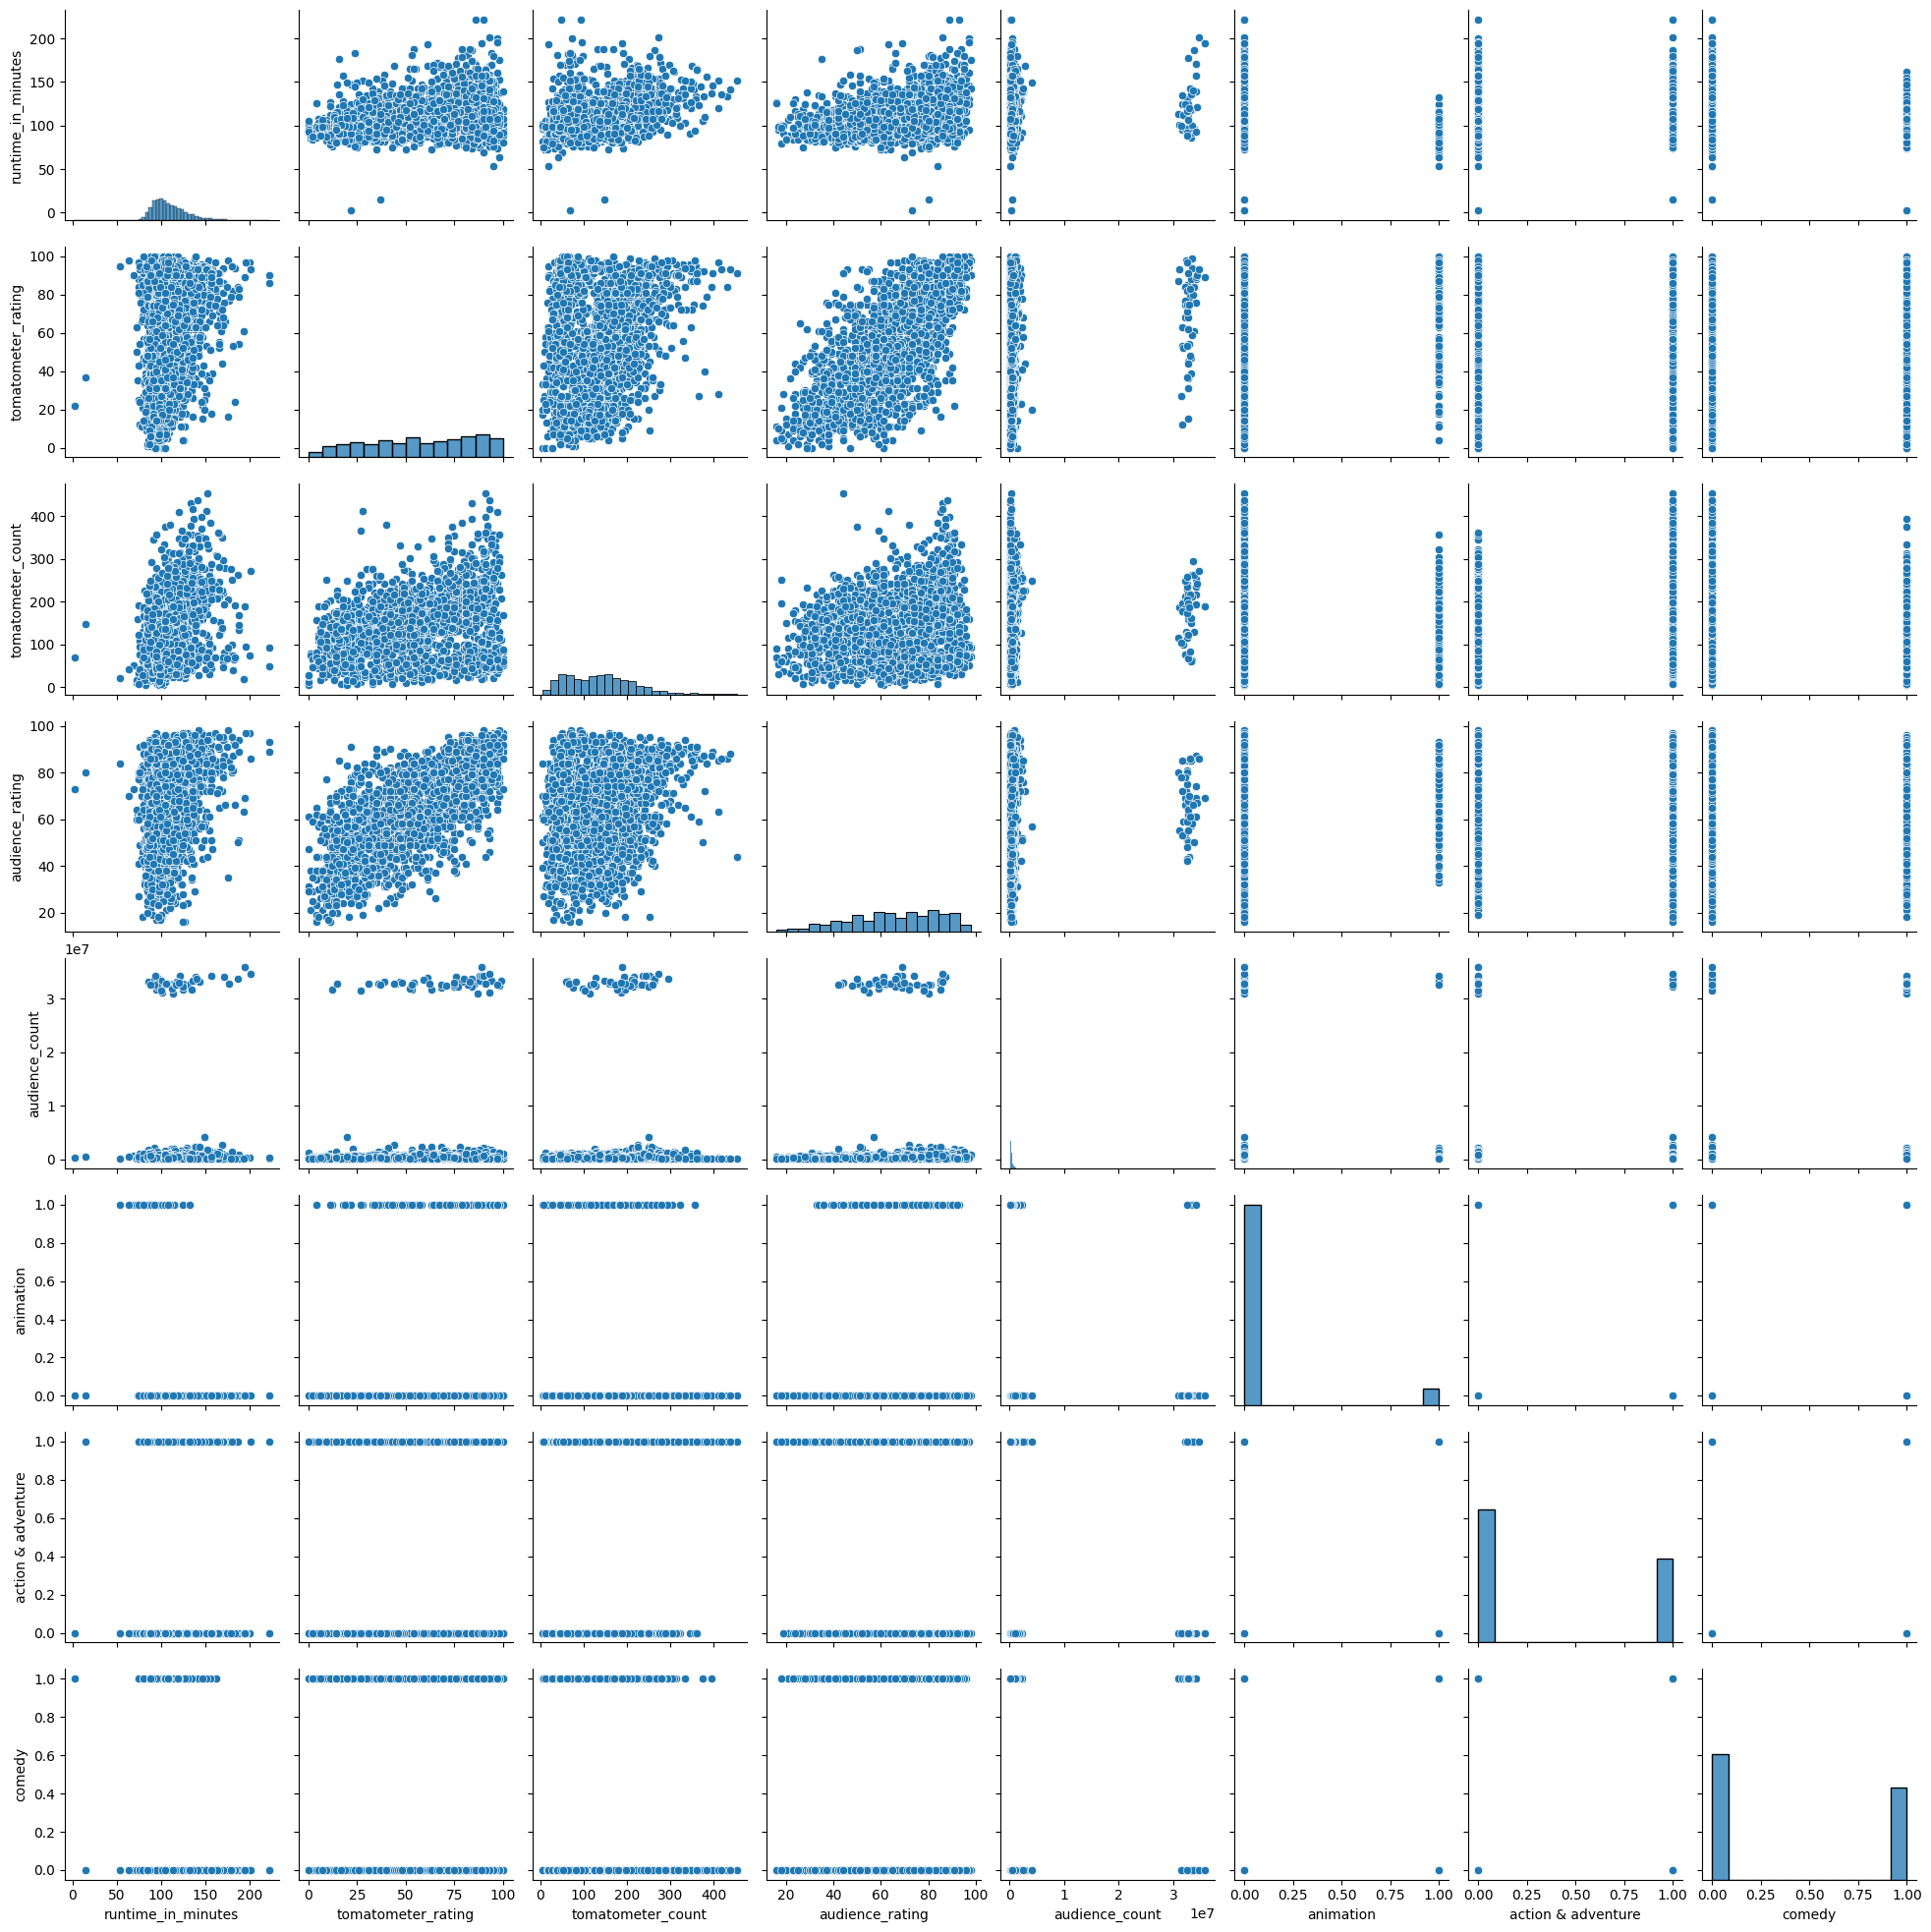

In [157]:
import seaborn as sns
sns.pairplot(popular_movies)

What insights can you gather from this pair plot?
* How do the critic ratings (tomatometer_rating) compare with the audience ratings (compare the histograms)?
* What are some surprising findings about the run times of movies compared with other fields (look at the scatter plots)?
* What is the most popular movie by far in terms of the number of audience ratings?

As previously noted, the audience ratings tend to skew higher than the critics' ratings. The runtime is not correlated with most other fields, except audience count, where shorter movies get more views. It looks like Titanic is the most popular movie. The audience and critic ratings are directly correlated. 

In [147]:
popular_movies.sort_values("audience_count", ascending=False)

,movie_title,rating,genre,in_theaters_date,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count,animation,action & adventure,comedy
15315,Titanic,PG-13,"Drama, Romance",1997-12-19,194.0,89,189,69.0,35797635.0,0,0,0
14506,The Lord of the Rings: The Return of the King,PG-13,"Action & Adventure, Classics, Science Fiction ...",2003-12-17,201.0,93,273,86.0,34679773.0,0,1,0
12924,Spider-Man,PG-13,"Action & Adventure, Mystery & Suspense, Scienc...",2002-05-03,121.0,90,243,67.0,34297354.0,0,1,0
12520,Shrek 2,PG,"Animation, Comedy, Kids & Family, Science Fict...",2004-05-19,93.0,89,236,69.0,34232524.0,1,0,1
7114,Harry Potter and the Goblet of Fire,PG-13,"Action & Adventure, Kids & Family, Science Fic...",2005-11-18,157.0,88,253,74.0,34153607.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9984,Moon,R,"Mystery & Suspense, Science Fiction & Fantasy",2009-06-12,97.0,90,193,89.0,100576.0,0,0,0
13003,Star Trek: First Contact,PG-13,"Action & Adventure, Science Fiction & Fantasy",1996-11-22,105.0,93,56,89.0,100556.0,0,1,0
13081,Step Up 3,PG-13,"Drama, Musical & Performing Arts, Romance",2010-08-06,107.0,47,120,64.0,100526.0,0,0,0
274,Repo Men,R,"Action & Adventure, Science Fiction & Fantasy",2010-03-19,119.0,22,151,41.0,100453.0,0,1,0
